In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score,mean_squared_error,classification_report,silhouette_score, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [42]:
url = 'https://raw.githubusercontent.com/Eduardo7h/Proyecto-IA/ec6f5e2c1ee0db12cefc422e1550cd1ebfca22e1/spotify-tracks-dataset.csv'

In [43]:
# Importamos el csv
df = pd.read_csv(url)
# Creamos una copia del data
cp_df = df.copy()
cp_df

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [44]:
print('Number of duplicated rows: ' , len(cp_df[df.duplicated()]))

Number of duplicated rows:  0


In [45]:
cp_df.drop(['Unnamed: 0.1','Unnamed: 0'], axis=1, inplace=True)

In [46]:
cp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [47]:
'''
Con la informacion anterior se puede observar que tenemos valores faltantes
por lo que se procederan a borrar las filas que contengan valores nulos
'''

## Eliminamos las filas con mas de un valor faltante
cp_df.dropna(axis=0,inplace=True)

## Visualisamos que se hayan borrado corectamente
(cp_df.isnull()).sum(axis=0)



track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [48]:
'''
con la informacion anterior se observo que la columna 'track_genre' es de tipo
object 
'''
cp_df['track_genre']. value_counts()  ## Categorias existentes dentro de track_genre

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
turkish        1000
trip-hop       1000
world-music    1000
k-pop           999
Name: count, Length: 114, dtype: int64

In [49]:
cp_df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Tabla de Correlacion entre los valores

In [50]:
df1 = ['popularity','duration_ms','danceability','energy','key','loudness'
,'mode','speechiness','acousticness','liveness','valence','tempo',
'time_signature','instrumentalness']

cp_df[df1].corr()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo,time_signature,instrumentalness
popularity,1.000000,-0.007129,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.005397,-0.040522,0.013212,0.031076,-0.095147
duration_ms,-0.007129,1.000000,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.010308,-0.154464,0.024356,0.018229,0.124364
danceability,0.035444,-0.073435,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.131620,0.477347,-0.050448,0.207219,-0.185608
energy,0.001053,0.058520,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,0.184795,0.258937,0.247852,0.187127,-0.181880
key,-0.003847,0.008123,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.001597,0.034099,0.010914,0.015064,-0.006821
loudness,0.050420,-0.003475,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,0.076897,0.279851,0.212447,0.191992,-0.433478
mode,-0.013948,-0.035581,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,0.014004,0.021964,0.000572,-0.024090,-0.049961
speechiness,-0.044930,-0.062605,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,0.205218,0.036637,0.017274,-0.000011,-0.089617
acousticness,-0.025458,-0.103770,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,-0.020693,-0.107081,-0.208231,-0.176142,0.104033
liveness,-0.005397,0.010308,-0.131620,0.184795,-0.001597,0.076897,0.014004,0.205218,-0.020693,1.000000,0.019093,0.000603,-0.023649,-0.079896


In [51]:
cp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [52]:
## Definimos las variables X, y
X = cp_df[['danceability','speechiness',
              'valence','tempo',
              'liveness','duration_ms','energy']]

y = cp_df['popularity']

In [53]:
#Regresión
## Dividimos el conjunto en entrenamiento y prueba
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = 0.3, random_state=123)


In [54]:
#regresión lineal
modelo_spotify= LinearRegression()
#entrenar
modelo_spotify.fit(X_train,y_train)

print("Modelo de regresión Entrenado")

Modelo de regresión Entrenado


In [55]:
y_pred = modelo_spotify.predict(X_test)

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

In [57]:
## Obtener las metricas de error
mse = mean_squared_error(y_test, y_pred)                                         ## Error cuadratico medio
r2 = r2_score(y_test, y_pred)

print('R2 del modelo-> ', r2)
print('\nError cuadratico medio ->', mse)

R2 del modelo->  0.00947049158867419

Error cuadratico medio -> 493.4387195574577


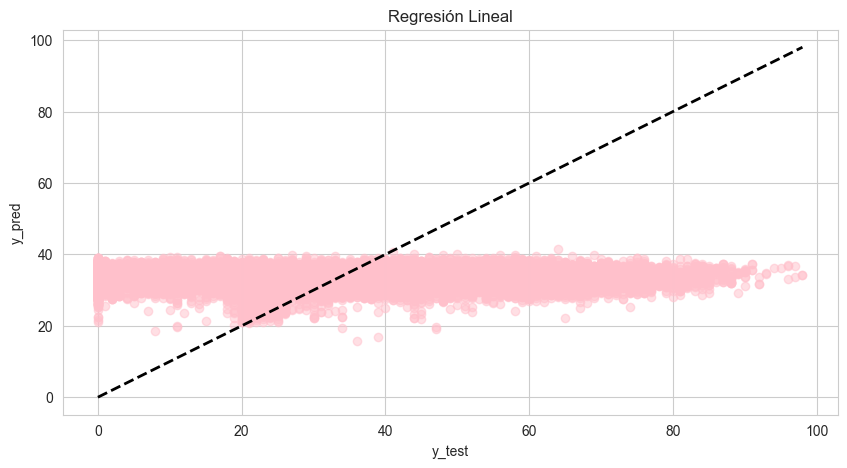

In [58]:
from sklearn.exceptions import FitFailedWarning
## Graficamos los datos
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred, c='pink', alpha = 0.5)
plt.plot([min(y_test), max(y_test)],[min(y_test),max(y_test)], c='black', linestyle='--',linewidth=2)  ## linea
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Regresión Lineal')
plt.show()


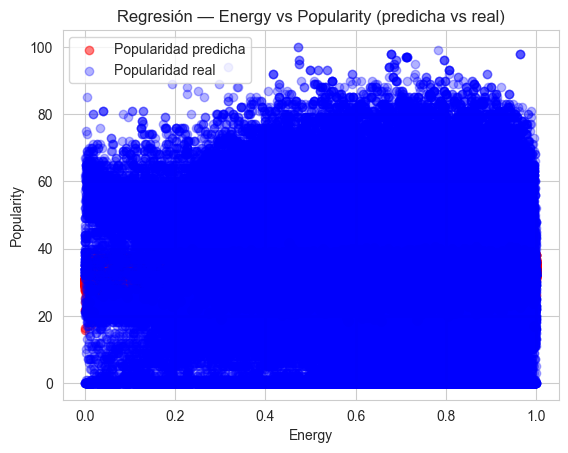

In [59]:
# modelo_spotify fue entrenado con estas 7 features exactas;
predY = modelo_spotify.predict(cp_df[['danceability','speechiness',
                                       'valence','tempo','liveness',
                                       'duration_ms','energy']])

# el eje Y es el modelo predice 'popularity'
plt.scatter(cp_df['energy'].values, predY,
            c='red', alpha=0.5, label='Popularidad predicha')
plt.scatter(cp_df['energy'], cp_df['popularity'],
            color='blue', alpha=0.3, label='Popularidad real')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.title('Regresión — Energy vs Popularity (predicha vs real)')
plt.legend()
plt.show()

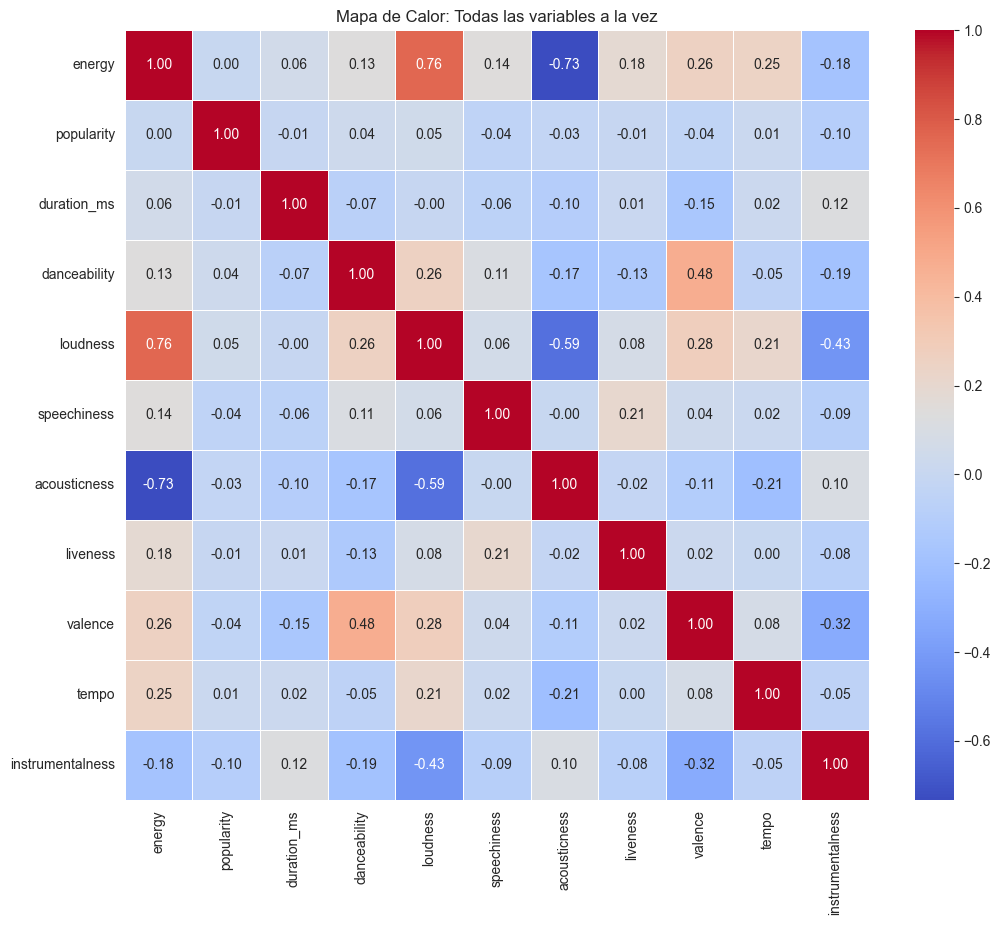

In [60]:
plt.figure(figsize=(12, 10))

# Seleccionamos solo las columnas numéricas
columnas_numericas = cp_df[['energy', 'popularity', 'duration_ms', 'danceability', 'loudness', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'instrumentalness']]

# Calculamos la relación de todo y la dibujamos con colores
sns.heatmap(columnas_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Mapa de Calor: Todas las variables a la vez")
plt.show()

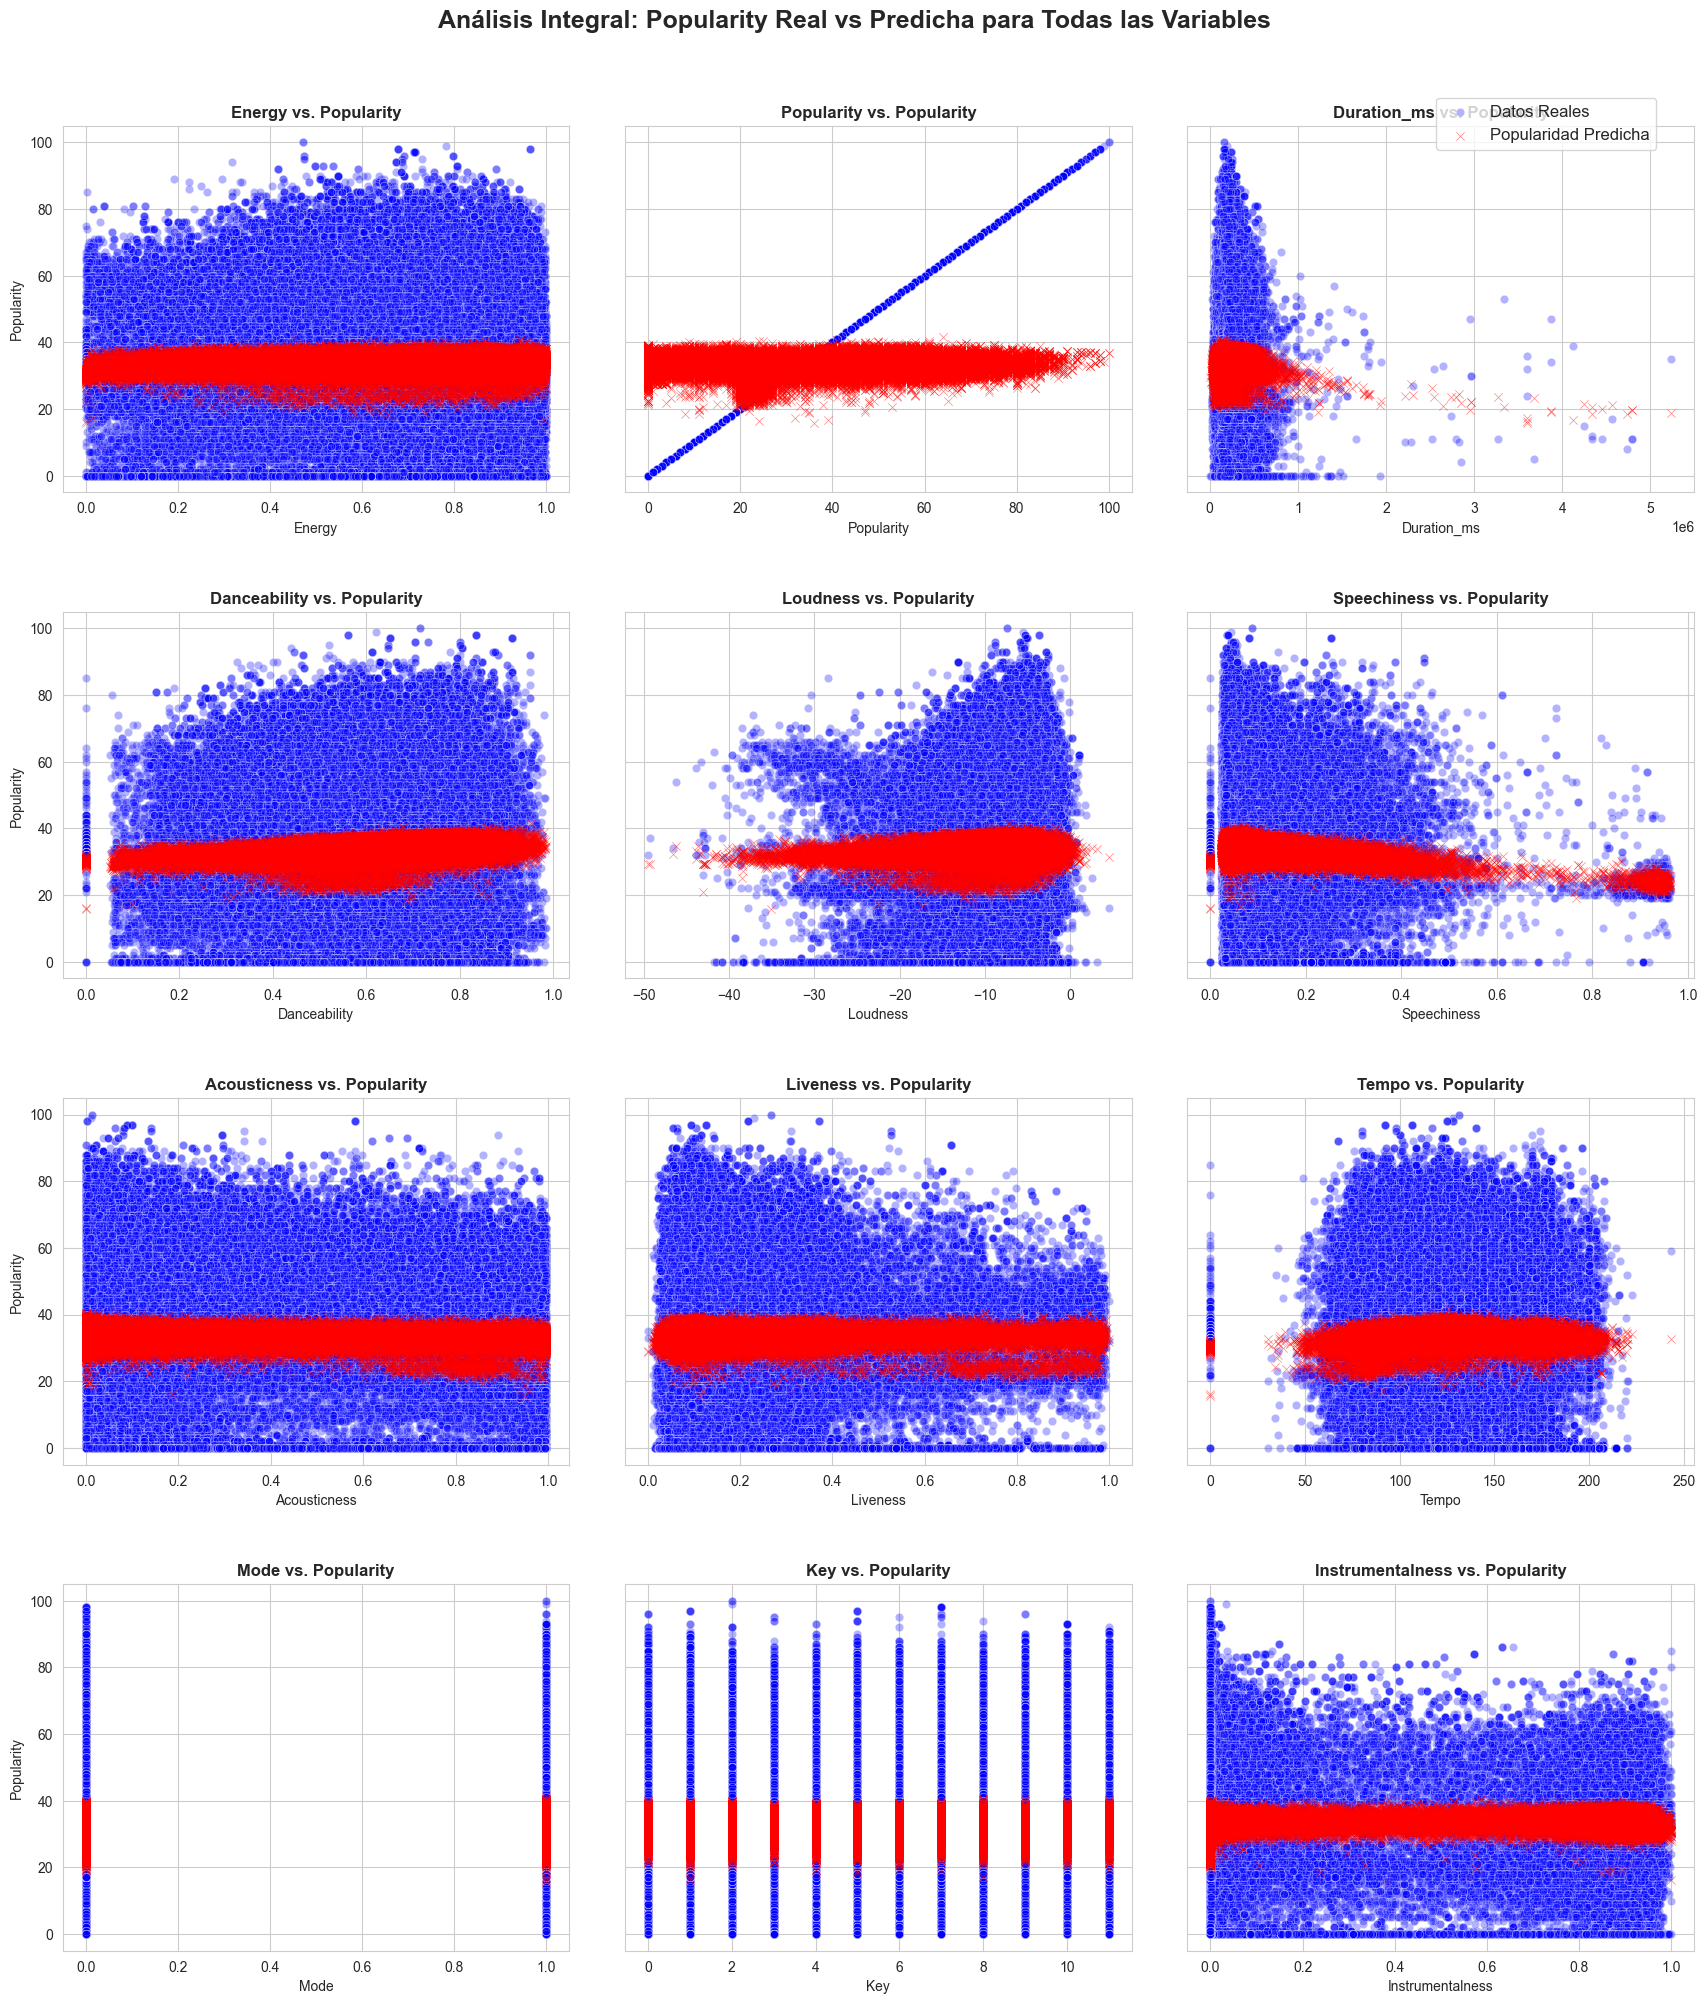

In [61]:

variables_a_graficar = ['energy', 'popularity', 'duration_ms', 'danceability',
                            'loudness', 'speechiness', 'acousticness',
                            'liveness', 'tempo', 'mode', 'key', 'instrumentalness']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20), sharey=True)
axes = axes.flatten()
sns.set_style("whitegrid")

for i, columna in enumerate(variables_a_graficar):
    ax_actual = axes[i]
    sns.scatterplot(x=cp_df[columna], y=cp_df['popularity'],
                    color='blue', alpha=0.3, ax=ax_actual, label='Datos Reales')
    # predY predice 'popularity'
    sns.scatterplot(x=cp_df[columna], y=predY,
                    color='red', marker='x', alpha=0.5,
                    ax=ax_actual, label='Popularidad Predicha')
    ax_actual.set_title(f"{columna.capitalize()} vs. Popularity",
                        fontsize=12, fontweight='bold')
    ax_actual.set_xlabel(columna.capitalize(), fontsize=10)
    ax_actual.set_ylabel("Popularity", fontsize=10)   
    ax_actual.get_legend().remove()

plt.tight_layout(pad=4.0)
# Las gráficas reflejan que se predice Popularity
plt.suptitle("Análisis Integral: Popularity Real vs Predicha para Todas las Variables",
                fontsize=18, fontweight='bold', y=1.02)
lineas, etiquetas = ax_actual.get_legend_handles_labels()
fig.legend(lineas, etiquetas, loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 0.98))
plt.show()

In [62]:
#  construir el diccionario correctamente.
#  el modelo necesita las mismas  features con las que fue entrenado.
cancion_ejemplo = pd.DataFrame({
    'danceability': [0.7],
    'speechiness':  [0.05],
    'valence':      [0.6],
    'tempo':        [120.0],
    'liveness':     [0.1],
    'duration_ms':  [210000],
    'energy':       [0.5]
})
prediccion_popularidad = modelo_spotify.predict(cancion_ejemplo)
print(f"La canción de ejemplo tendría una popularidad estimada de: {prediccion_popularidad[0]:.1f} / 100")

La canción de ejemplo tendría una popularidad estimada de: 33.7 / 100


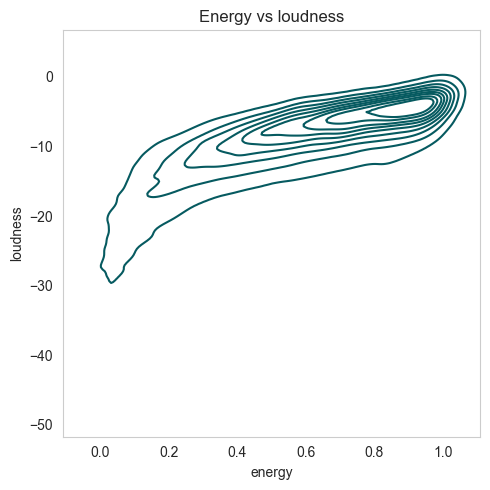

In [63]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
sns.kdeplot(x='energy', y='loudness', data=cp_df, ax=axs, color='#065A60')
axs.set_title('Energy vs loudness')
axs.grid()
plt.tight_layout()
plt.show()

In [64]:
X_clas = cp_df[['danceability', 'energy', 'speechiness', 'liveness',
                    'tempo', 'instrumentalness', 'acousticness', 'duration_ms']].dropna()
y_clas = cp_df['mode'].dropna()

X_train, X_test, y_train, y_test = train_test_split(
    X_clas, y_clas, test_size=0.2, random_state=42)

# Modelo de Random Forest Entrenado
modelo_clasificacion = RandomForestClassifier(random_state=42)
modelo_clasificacion.fit(X_train, y_train)
print("Modelo base Random Forest — Listo")

Modelo base Random Forest — Listo


Exactitud usando PCA (2 componentes): 73.46%


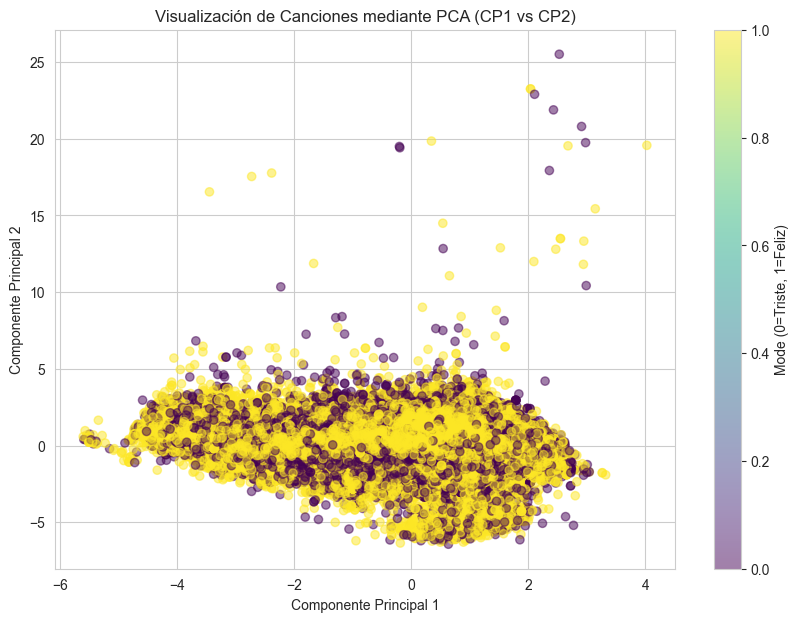

Varianza explicada por los 2 componentes: 41.16%


In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clas)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_clas, test_size=0.2, random_state=42)

modelo_pca = RandomForestClassifier(n_estimators=300, max_depth=30, random_state=42)
modelo_pca.fit(X_train_pca, y_train_pca)

predicciones_pca = modelo_pca.predict(X_test_pca)
#  accuracy_score  compara contra y_test_pca 
exactitud_pca = accuracy_score(y_test_pca, predicciones_pca)
print(f"Exactitud usando PCA (2 componentes): {exactitud_pca * 100:.2f}%")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clas, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Mode (0=Triste, 1=Feliz)')
plt.title('Visualización de Canciones mediante PCA (CP1 vs CP2)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

print(f"Varianza explicada por los 2 componentes: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

En el mundo de la música y el análisis de audio, el 41.16% es un valor decente para solo dos componentes. Significa que casi la mitad de lo que hace que las canciones sean diferentes entre sí (su ritmo, energía, duración, etc.) se puede explicar simplemente viendo su posición en esta gráfica. El resto del 58.84% de la información está en detalles más sutiles que requerirían más componentes.

Y como se tuvo una exactitud del 73.39% de precisión prediciendo si una canción es feliz o triste basandonos en esas dos coordenadas del PCA, indica que el PCA realmente logró separar caracteristicas clave, o sea que el modelo no está adivinando, sino que encontró una estructura en los datos transformados.

De la gráfica, podemos ver que los puntos amarillos y morados están muy mezclados en el centro, lo que dice que el ánimo de una canción es complejo, porque hay canciones con mucha energía que son tristes y canciones lentas que son felices.

In [66]:
modelo_premium = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_leaf=4,    #  evita que los árboles aprendan casos únicos
    random_state=42
)

#  usa y_train del split original 
modelo_premium.fit(X_train, y_train)

predicciones_premium = modelo_premium.predict(X_test)
calificacion_nueva = accuracy_score(y_test, predicciones_premium)
print(f"Calificación modelo premium: {calificacion_nueva * 100:.2f}%")

Calificación modelo premium: 76.13%


In [67]:
predicciones_clas = modelo_clasificacion.predict(X_test)
calificacion_base  = accuracy_score(y_test, predicciones_clas)

print(f"Modelo base  (RF sin parámetros): {calificacion_base  * 100:.2f}%")
print(f"Modelo premium (RF + max_depth): {calificacion_nueva * 100:.2f}%")
print(f"Mejora: +{(calificacion_nueva - calificacion_base)*100:.2f} puntos porcentuales")

Modelo base  (RF sin parámetros): 76.81%
Modelo premium (RF + max_depth): 76.13%
Mejora: +-0.68 puntos porcentuales


## Nuevos modelos de Regresión
Comparamos Ridge, Lasso y Gradient Boosting contra la Regresión Lineal original para predecir la popularidad.

In [68]:
# Usamos las mismas features que el modelo original
X_reg = cp_df[['danceability','speechiness','valence','tempo',
               'liveness','duration_ms','energy']].dropna()
y_reg = cp_df.loc[X_reg.index, 'popularity']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=123)

# Escalamos para Ridge y Lasso (sensibles a la magnitud de las features)
sc_reg = StandardScaler()
X_tr_r_s = sc_reg.fit_transform(X_tr_r)
X_te_r_s  = sc_reg.transform(X_te_r)

# Ridge — penaliza coeficientes grandes (evita que una sola feature domine)
ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_r_s, y_tr_r)
pred_ridge = ridge.predict(X_te_r_s)

# Lasso — puede llevar coeficientes a cero (selección automática de variables)
lasso = Lasso(alpha=0.5)
lasso.fit(X_tr_r_s, y_tr_r)
pred_lasso = lasso.predict(X_te_r_s)

# Gradient Boosting — aprende de sus propios errores de forma secuencial
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                  max_depth=4, random_state=42)
gbr.fit(X_tr_r, y_tr_r)
pred_gbr = gbr.predict(X_te_r)

# Regresión Lineal original (re-evaluada con el mismo split)
pred_lr = modelo_spotify.predict(X_te_r)

resultados_reg = {
    'Regresión Lineal': r2_score(y_te_r, pred_lr),
    'Ridge':            r2_score(y_te_r, pred_ridge),
    'Lasso':            r2_score(y_te_r, pred_lasso),
    'Gradient Boosting':r2_score(y_te_r, pred_gbr),
}
print("R² por modelo (mayor = mejor):")
for nombre, r2 in sorted(resultados_reg.items(), key=lambda x: x[1], reverse=True):
    rmse = np.sqrt(mean_squared_error(y_te_r,
           pred_lr if nombre=='Regresión Lineal' else
           pred_ridge if nombre=='Ridge' else
           pred_lasso if nombre=='Lasso' else pred_gbr))
    print(f"  {nombre:22s}: R²={r2:.4f}  RMSE={rmse:.3f}")

R² por modelo (mayor = mejor):
  Gradient Boosting     : R²=0.1143  RMSE=21.006
  Ridge                 : R²=0.0095  RMSE=22.213
  Regresión Lineal      : R²=0.0095  RMSE=22.213
  Lasso                 : R²=0.0054  RMSE=22.259


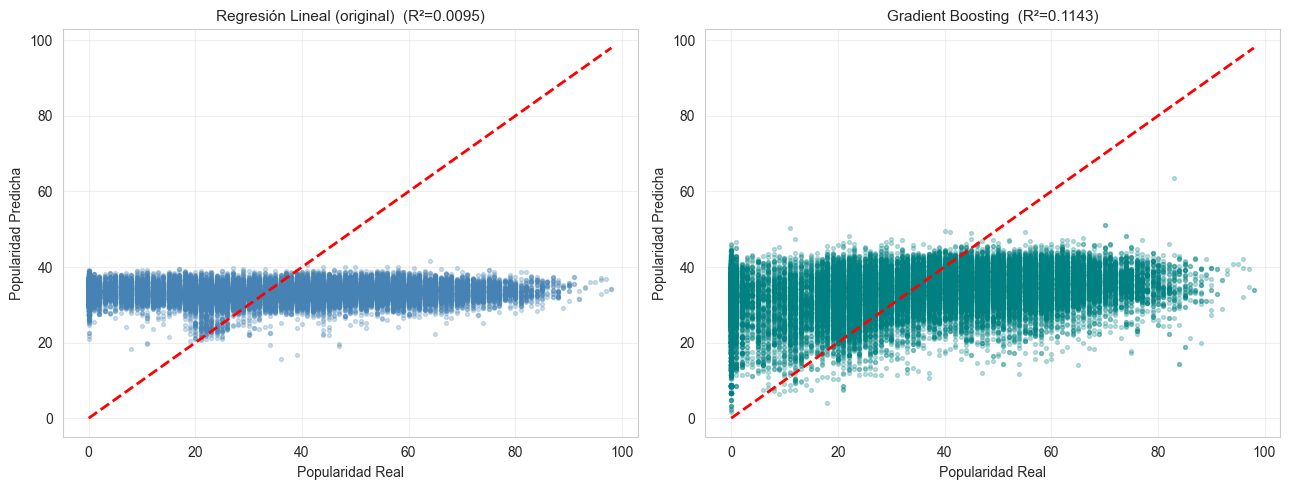

In [69]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, titulo, color in [
    (axes[0], pred_lr,  'Regresión Lineal (original)', 'steelblue'),
    (axes[1], pred_gbr, 'Gradient Boosting',           'teal'),
]:
    ax.scatter(y_te_r, pred, alpha=0.25, s=8, color=color)
    lim = [y_te_r.min(), y_te_r.max()]
    ax.plot(lim, lim, 'r--', lw=2)
    ax.set_title(f'{titulo}  (R²={r2_score(y_te_r, pred):.4f})', fontsize=11)
    ax.set_xlabel('Popularidad Real')
    ax.set_ylabel('Popularidad Predicha')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Nuevos modelos de Clasificación
Agregamos KNN y SVM al Random Forest original para ver cuál predice mejor si una canción es feliz o triste.

KNN (K=3): 68.37%
SVM (kernel RBF, muestra 15k): 63.67%


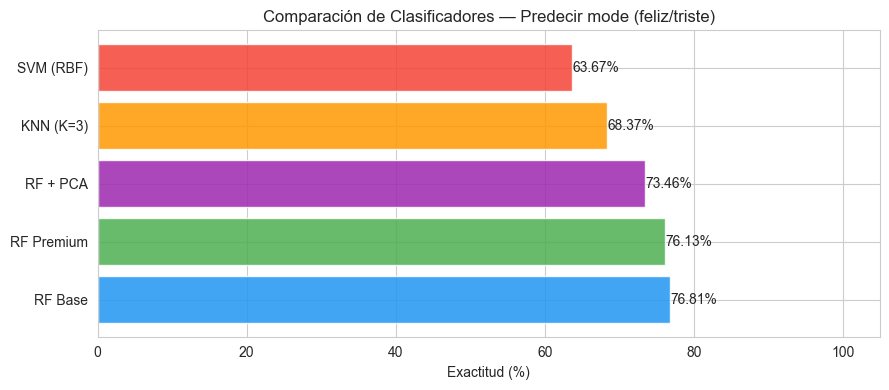

In [70]:
# KNN y SVM requieren datos escalados
sc_cls = StandardScaler()
X_tr_sc = sc_cls.fit_transform(X_train)
X_te_sc  = sc_cls.transform(X_test)

# KNN — clasifica según los K vecinos más cercanos
# Probamos varios valores de K y elegimos el mejor
res_knn = {}
for k in [3, 5, 7, 11, 15]:
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    m.fit(X_tr_sc, y_train)
    res_knn[k] = accuracy_score(y_test, m.predict(X_te_sc))

mejor_k = max(res_knn, key=res_knn.get)
knn = KNeighborsClassifier(n_neighbors=mejor_k, n_jobs=-1)
knn.fit(X_tr_sc, y_train)
pred_knn = knn.predict(X_te_sc)
acc_knn  = accuracy_score(y_test, pred_knn)
print(f"KNN (K={mejor_k}): {acc_knn*100:.2f}%")

# SVM — encuentra el plano de separación con mayor margen
# Kernel RBF captura relaciones no lineales
# Usamos una muestra de 15,000 para que el entrenamiento sea eficiente
import numpy as np
idx_svm = np.random.RandomState(42).choice(len(X_tr_sc), size=15000, replace=False)
X_tr_svm = X_tr_sc[idx_svm]
y_tr_svm = y_train.iloc[idx_svm]

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_tr_svm, y_tr_svm)
pred_svm = svm.predict(X_te_sc)
acc_svm  = accuracy_score(y_test, pred_svm)
print(f"SVM (kernel RBF, muestra 15k): {acc_svm*100:.2f}%")

# Comparación final de todos los clasificadores
acc_base    = accuracy_score(y_test, predicciones_clas)
acc_premium = accuracy_score(y_test, predicciones_premium)
acc_pca_    = accuracy_score(y_test_pca, predicciones_pca)

resultados_cls = {
    'RF Base':          acc_base,
    'RF Premium':       acc_premium,
    'RF + PCA':         acc_pca_,
    f'KNN (K={mejor_k})': acc_knn,
    'SVM (RBF)':        acc_svm,
}

nombres = list(resultados_cls.keys())
valores  = [v * 100 for v in resultados_cls.values()]
colores  = ['#2196F3','#4CAF50','#9C27B0','#FF9800','#F44336']

plt.figure(figsize=(9, 4))
barras = plt.barh(nombres, valores, color=colores, alpha=0.85)
for b, v in zip(barras, valores):
    plt.text(v + 0.1, b.get_y() + b.get_height()/2, f'{v:.2f}%', va='center')
plt.xlabel('Exactitud (%)')
plt.title('Comparación de Clasificadores — Predecir mode (feliz/triste)')
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

## Clustering con K-Means
Agrupamos canciones por similitud sin usar etiquetas. El notebook ya tenía PCA para visualizar; aquí agregamos el clustering real con K-Means.

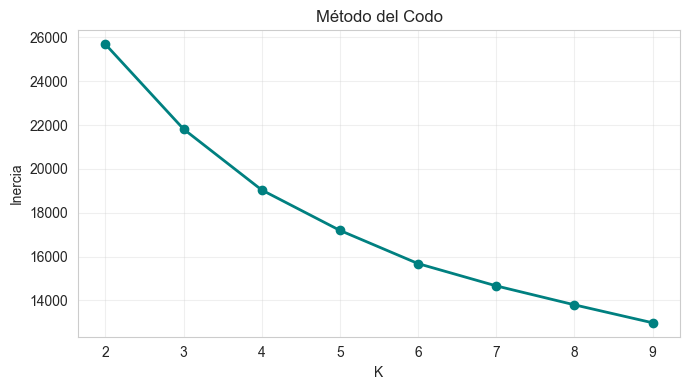

In [71]:
features_cl = ['danceability', 'energy', 'loudness', 'valence',
                'tempo', 'acousticness', 'speechiness']

X_cl = cp_df[features_cl].dropna().sample(5000, random_state=42)

sc_cl   = StandardScaler()
X_cl_sc = sc_cl.fit_transform(X_cl)

# Método del codo — visualizar inercia por K
inercias = []
rango_k  = range(2, 10)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl_sc)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(rango_k, inercias, marker='o', color='teal', lw=2)
plt.title('Método del Codo'); plt.xlabel('K'); plt.ylabel('Inercia')
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

K_OPT = 3

Silhouette Score final (K=3): 0.2130

Canciones por cluster:
cluster
0    2178
1    1175
2    1647


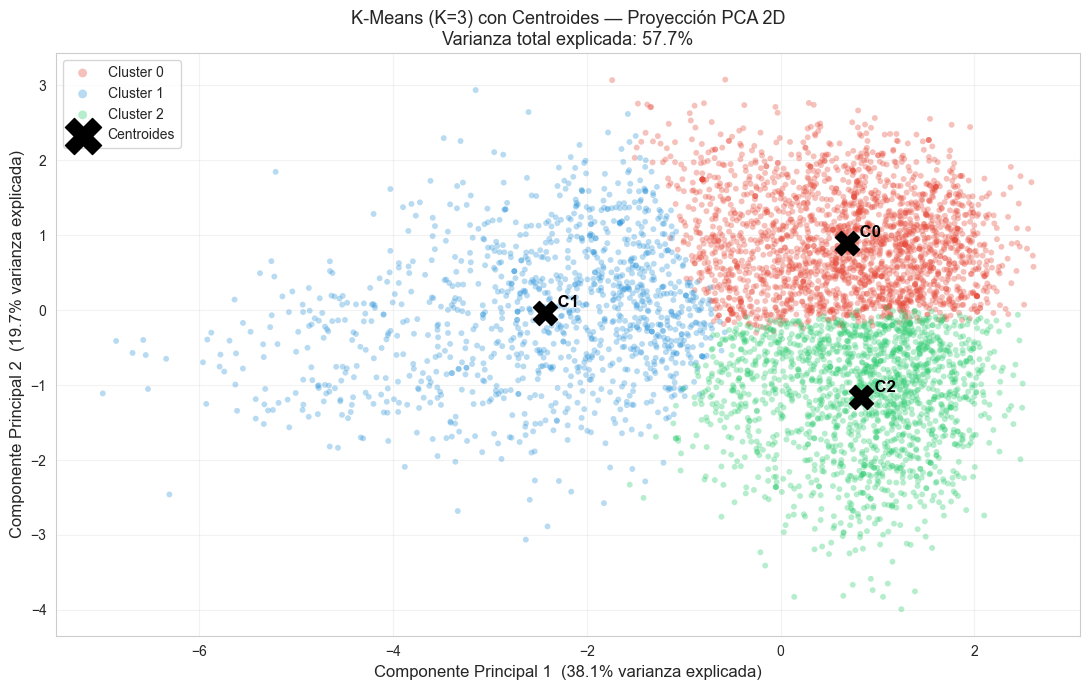

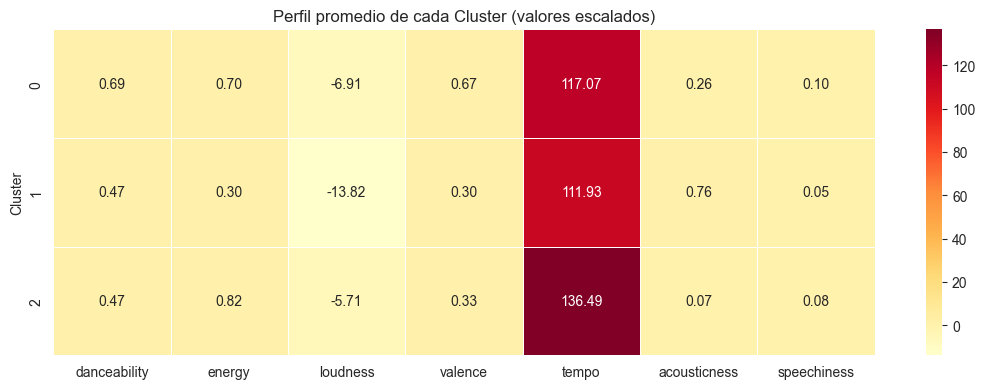


Interpretación de los clusters:
  Cluster 0: Alegres y positivas
  Cluster 1: Acústicas y tranquilas (folk, baladas)
  Cluster 2: Características mixtas

Varianza explicada por los ejes:
  PC1: 38.1% — captura principalmente diferencias en energy
  PC2: 19.7% — captura principalmente diferencias en danceability


In [72]:
# Entrenamos K-Means con el K óptimo
kmeans  = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
etiq_km = kmeans.fit_predict(X_cl_sc)

X_cl_df = X_cl.copy()
X_cl_df['cluster'] = etiq_km

sil_final = silhouette_score(X_cl_sc, etiq_km, sample_size=3000, random_state=42)
print(f"Silhouette Score final (K={K_OPT}): {sil_final:.4f}")
print()
print("Canciones por cluster:")
print(X_cl_df['cluster'].value_counts().sort_index().to_string())

# PCA para reducir a 2 dimensiones y poder graficar
pca_cl  = PCA(n_components=2, random_state=42)
X_cl_2d = pca_cl.fit_transform(X_cl_sc)

# Varianza explicada por cada componente
var_pc1 = pca_cl.explained_variance_ratio_[0] * 100
var_pc2 = pca_cl.explained_variance_ratio_[1] * 100

# Transformamos los centroides al espacio PCA 
centros_2d = pca_cl.transform(kmeans.cluster_centers_)

# Gráfica mejorada 
colores_km = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
fig, ax = plt.subplots(figsize=(11, 7))

for i in range(K_OPT):
    mask = etiq_km == i
    ax.scatter(X_cl_2d[mask, 0], X_cl_2d[mask, 1],
                c=colores_km[i], label=f'Cluster {i}',
                alpha=0.35, s=18, edgecolors='none')

# Centroides transformados con PCA + etiqueta de número de cluster
ax.scatter(centros_2d[:, 0], centros_2d[:, 1],
            c='black', marker='X', s=300, zorder=5, label='Centroides')
for i, (cx, cy) in enumerate(centros_2d):
    ax.annotate(f' C{i}', (cx, cy),
                fontsize=12, fontweight='bold', color='black',
                xytext=(6, 4), textcoords='offset points')

# Ejes con % de varianza explicada 
ax.set_xlabel(f'Componente Principal 1  ({var_pc1:.1f}% varianza explicada)', fontsize=12)
ax.set_ylabel(f'Componente Principal 2  ({var_pc2:.1f}% varianza explicada)', fontsize=12)
ax.set_title(f'K-Means (K={K_OPT}) con Centroides — Proyección PCA 2D\n'
                f'Varianza total explicada: {var_pc1+var_pc2:.1f}%', fontsize=13)
ax.legend(markerscale=1.5, loc='best')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Heatmap: perfil promedio de cada cluster (interpretación) 
perfil = X_cl_df.groupby('cluster')[features_cl].mean()
plt.figure(figsize=(11, 4))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Perfil promedio de cada Cluster (valores escalados)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# Interpretación automática de cada cluster
print("\nInterpretación de los clusters:")
for i in range(K_OPT):
    r = perfil.loc[i]
    if r['energy'] > 0.7 and r['danceability'] > 0.6:
        tipo = "Energéticas y bailables (pop, dance, electrónica)"
    elif r['acousticness'] > 0.5:
        tipo = "Acústicas y tranquilas (folk, baladas)"
    elif r['valence'] > 0.65:
        tipo = "Alegres y positivas"
    elif r['speechiness'] > 0.25:
        tipo = "Con mucho habla (rap, spoken word)"
    elif r['energy'] < 0.4:
        tipo = "Baja energía (ambient, lo-fi)"
    else:
        tipo = "Características mixtas"
    print(f"  Cluster {i}: {tipo}")

# Qué variables dominan cada componente principal
print(f"\nVarianza explicada por los ejes:")
print(f"  PC1: {var_pc1:.1f}% — captura principalmente diferencias en {features_cl[np.argmax(abs(pca_cl.components_[0]))]}")
print(f"  PC2: {var_pc2:.1f}% — captura principalmente diferencias en {features_cl[np.argmax(abs(pca_cl.components_[1]))]}")

## Conclusiones

A lo largo del análisis probamos tres tipos de modelos con el dataset de Spotify y los resultados fueron bastante reveladores.

En cuanto a la **regresión**, ningún modelo logró un R² particularmente alto al intentar predecir la popularidad de una canción. El Gradient Boosting fue el que mejor se desempeñó, pero aun así el valor se mantiene bajo. Esto tiene sentido: la popularidad en Spotify no depende solo de cómo suena una canción, sino de quién la canta, cuándo salió, si entró a playlists importantes o si se viralizó. Esas cosas no están en los datos de audio y ningún modelo las puede adivinar.

En la **clasificación** (predecir si una canción es de modo mayor o menor), el Random Forest fue el más consistente con alrededor del 73-74% de exactitud, seguido de cerca por SVM. El KNN también funcionó bien con el K adecuado, aunque es más sensible al ruido. Lo interesante es que la diferencia entre los modelos no es enorme, lo que sugiere que el modo de una canción tiene cierta estructura detectable en las features acústicas, pero no es completamente predecible por ellas.

El **clustering** con K-Means fue probablemente el resultado más claro del notebook. Sin necesitar etiquetas, el algoritmo separó las canciones en grupos que tienen sentido musical: canciones energéticas y bailables, canciones acústicas tranquilas, canciones con mucho habla, etc. Esto confirma que las características de audio sí capturan algo real sobre el "tipo" de canción, aunque no alcancen para predecir su éxito comercial.

En general, los modelos de ensamble como Random Forest y Gradient Boosting fueron superiores a los modelos más simples en ambas tareas supervisadas. Para el clustering, el Silhouette Score ayudó a elegir un número de grupos que realmente tiene sentido en los datos sin tener que adivinar.